In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [5]:
df = pd.read_csv(r'airline_passengers.csv', index_col = 'Month', parse_dates = True)

In [6]:
df.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

In [7]:
df.index.freq = 'MS'

In [8]:
Ntest = 12 
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [10]:
train_idx = df.index <= train.index[-1] 
test_idx = df.index > train.index[-1]
# train_idx

In [11]:
hw = ExponentialSmoothing(
    train['Passengers']
    # , initialization_method = 'legacy-heuristic'
    ,trend ='add', seasonal ='add', seasonal_periods = 12)

res_hw = hw.fit()
    

In [12]:
res_hw.params

{'smoothing_level': np.float64(0.25112616412071553),
 'smoothing_trend': np.float64(0.0),
 'smoothing_seasonal': np.float64(0.7488738358792845),
 'damping_trend': nan,
 'initial_level': np.float64(118.54414324923133),
 'initial_trend': np.float64(2.5577286940517463),
 'initial_seasons': array([ -9.09188179,  -3.51657886,   8.97900309,   3.77152666,
         -4.95283107,   9.16650688,  21.36482925,  18.90277272,
          4.68894961, -14.24308584, -28.86590027, -12.48289504]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [13]:
""" the simple exponential smoothing and holt linear model which we had trained earlier, we had seen that
level alpha was almost 1, meaning since seasonality cant be worked on by those models, they were just taking in the last known value.
But with holt winter and its ability to detect the seasonality , now its not putting so much weightage to last value of actuals 
and hence alpha is 0.25 only"""

' the simple exponential smoothing and holt linear model which we had trained earlier, we had seen that\nlevel alpha was almost 1, meaning since seasonality cant be worked on by those models, they were just taking in the last known value.\nBut with holt winter and its ability to detect the seasonality , now its not putting so much weightage to last value of actuals \nand hence alpha is 0.25 only'

In [14]:
df.loc[train_idx, 'HoltWinters'] = res_hw.fittedvalues
df.loc[test_idx, 'HoltWinters'] = res_hw.forecast(Ntest)

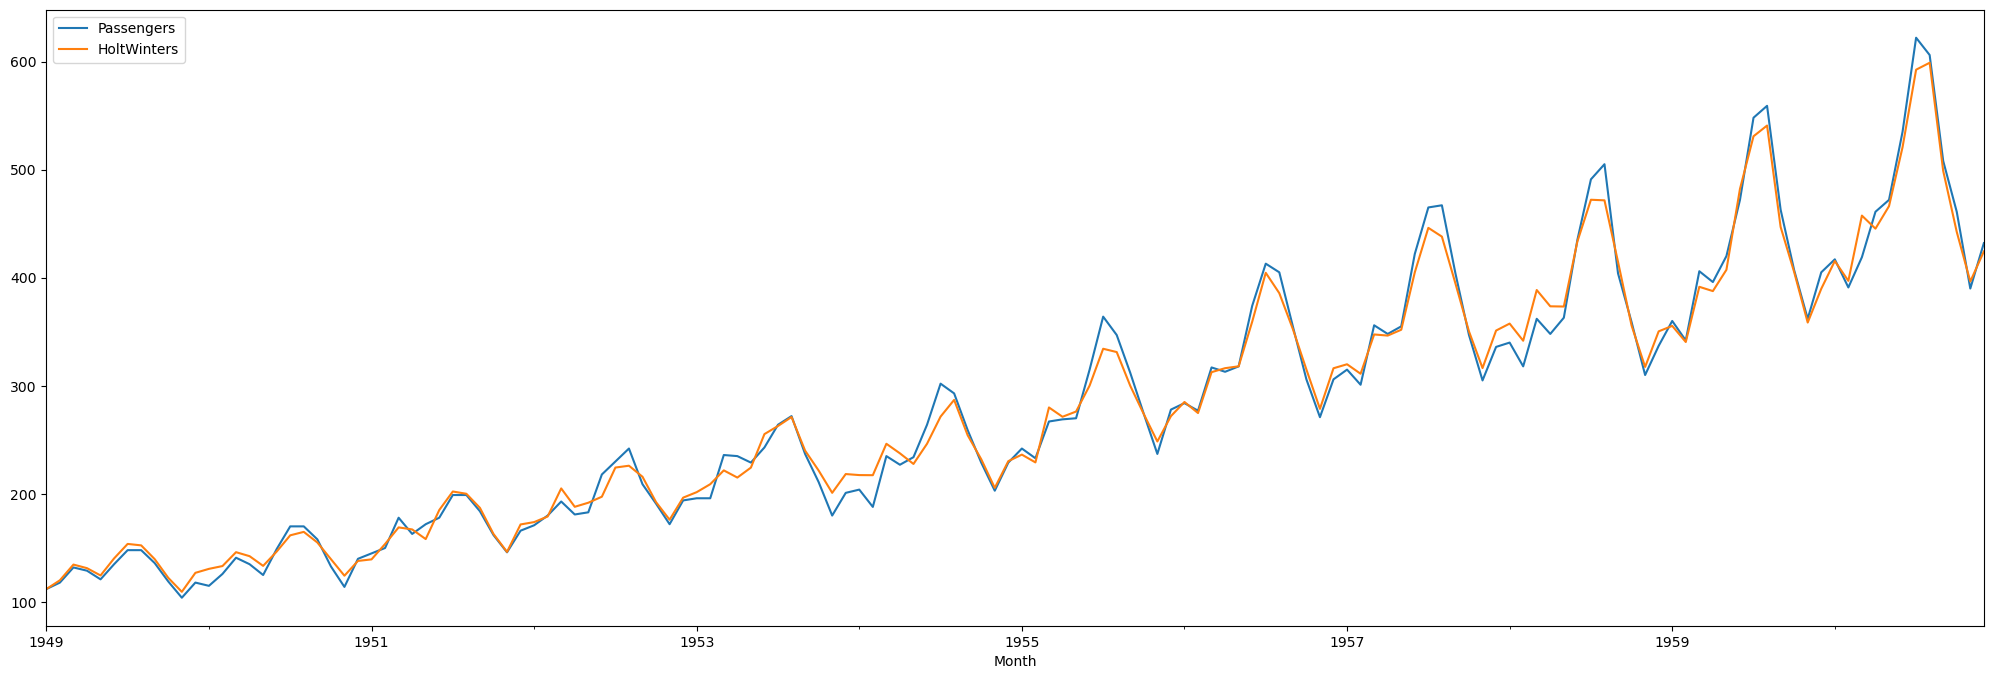

In [15]:
df[['Passengers','HoltWinters']].plot(figsize = (25,8));

In [16]:
""" this is AWESOME - remember that in the holt linear and simple exponential smnoothing, the test data was not fitting well
but, here test data is also fitting very very well"""

' this is AWESOME - remember that in the holt linear and simple exponential smnoothing, the test data was not fitting well\nbut, here test data is also fitting very very well'

In [17]:
"""ALSO, NOTICE THAT THE PREDICTIONS ARE NOT LAGGING BEHIND THE TIME SERIES AS BEING OBSERVED IN THE HOLT LINEAR AND 
SIMPLE EXPONENTIAL SMOOTHIN

HENCE, NEVER EVER SHIFT THE NUMBERS AS DESCRIBED IN OTHER MODEL NOTEBOOKS. 
WHY DID IT APPEAR TO BE LAGGING IN HOLT LINEAR AND SIMPLE EXPONENTIAL?
reason was since they had no seasonal component, alpha for both the above model for level was close to 1 so that we get the least SSE (sum of squared errors)
when fitting those models"""

'ALSO, NOTICE THAT THE PREDICTIONS ARE NOT LAGGING BEHIND THE TIME SERIES AS BEING OBSERVED IN THE HOLT LINEAR AND \nSIMPLE EXPONENTIAL SMOOTHIN\n\nHENCE, NEVER EVER SHIFT THE NUMBERS AS DESCRIBED IN OTHER MODEL NOTEBOOKS. \nWHY DID IT APPEAR TO BE LAGGING IN HOLT LINEAR AND SIMPLE EXPONENTIAL?\nreason was since they had no seasonal component, alpha for both the above model for level was close to 1 so that we get the least SSE (sum of squared errors)\nwhen fitting those models'

In [18]:
def rmse(y,t):
    return np.sqrt(np.mean((y-t)**2))

In [19]:
def mae(y,t):
    return np.mean(abs(y-t))

In [24]:
print("Train RMSE:", rmse(train['Passengers'], res_hw.fittedvalues))
print("Test RMSE:", rmse(test['Passengers'], res_hw.forecast(Ntest)))

Train RMSE: 11.624680247338345
Test RMSE: 16.979663509487658


In [25]:
print("Train MAE:", mae(train['Passengers'], res_hw.fittedvalues))
print("Test MAE:", mae(test['Passengers'], res_hw.forecast(Ntest)))

Train MAE: 9.008279353734443
Test MAE: 13.380100540794189


## trying holt winters model again with different parameters


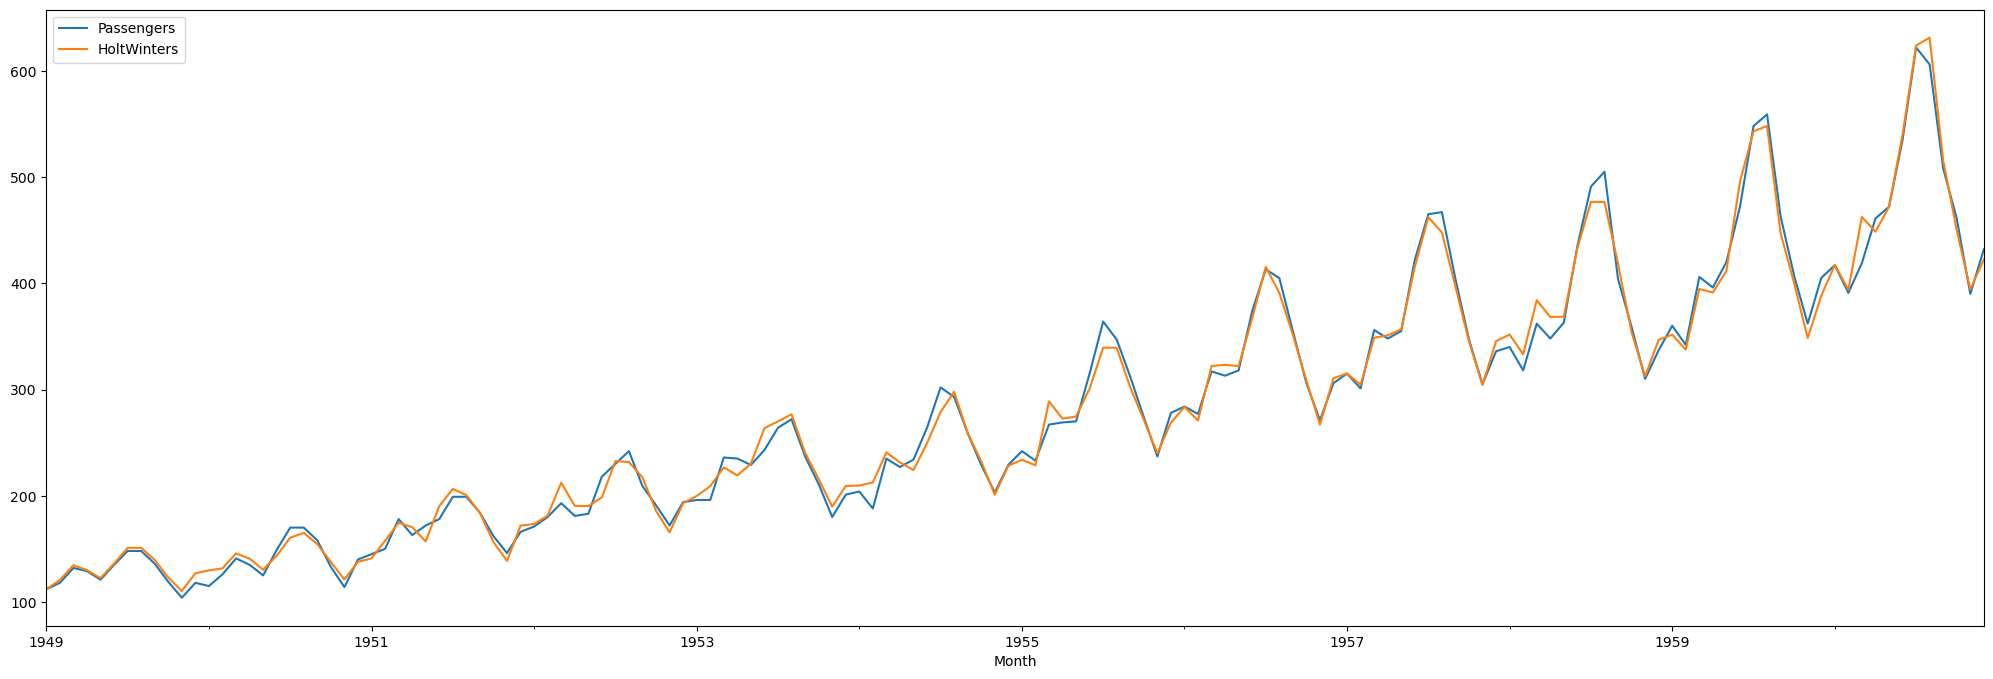

In [28]:
hw = ExponentialSmoothing(
    train['Passengers']
    # , initialization_method = 'legacy-heuristic'
    ,trend ='add', seasonal ='mul', seasonal_periods = 12)

""" seems like the amplitude of seasonality increases with the level of time series hence using seasonal = mul"""

res_hw = hw.fit()
df.loc[train_idx, 'HoltWinters'] = res_hw.fittedvalues
df.loc[test_idx, 'HoltWinters'] = res_hw.forecast(Ntest)    
df[['Passengers','HoltWinters']].plot(figsize = (25,8));

In [29]:
res_hw.params

{'smoothing_level': np.float64(0.3762221547218994),
 'smoothing_trend': np.float64(9.600334107514362e-09),
 'smoothing_seasonal': np.float64(0.6237778443336662),
 'damping_trend': nan,
 'initial_level': np.float64(108.54781032505372),
 'initial_trend': np.float64(2.6283648358150726),
 'initial_seasons': array([1.00739975, 1.06054906, 1.16567449, 1.10818845, 1.0241081 ,
        1.1194825 , 1.21824613, 1.20217591, 1.0960882 , 0.95551768,
        0.8498438 , 0.98014375]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [30]:
print("Train RMSE:", rmse(train['Passengers'], res_hw.fittedvalues))
print("Test RMSE:", rmse(test['Passengers'], res_hw.forecast(Ntest)))

Train RMSE: 9.767995274184017
Test RMSE: 15.810478481502829


In [31]:
print("Train MAE:", mae(train['Passengers'], res_hw.fittedvalues))
print("Test MAE:", mae(test['Passengers'], res_hw.forecast(Ntest)))

Train MAE: 7.604258612560486
Test MAE: 10.303248668883532


In [33]:
# results are better than additive one before 
# both test and train metrics better in both rmse and mae

## trying holt winters model again with different parameters


C:\Users\VARUN\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:84: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


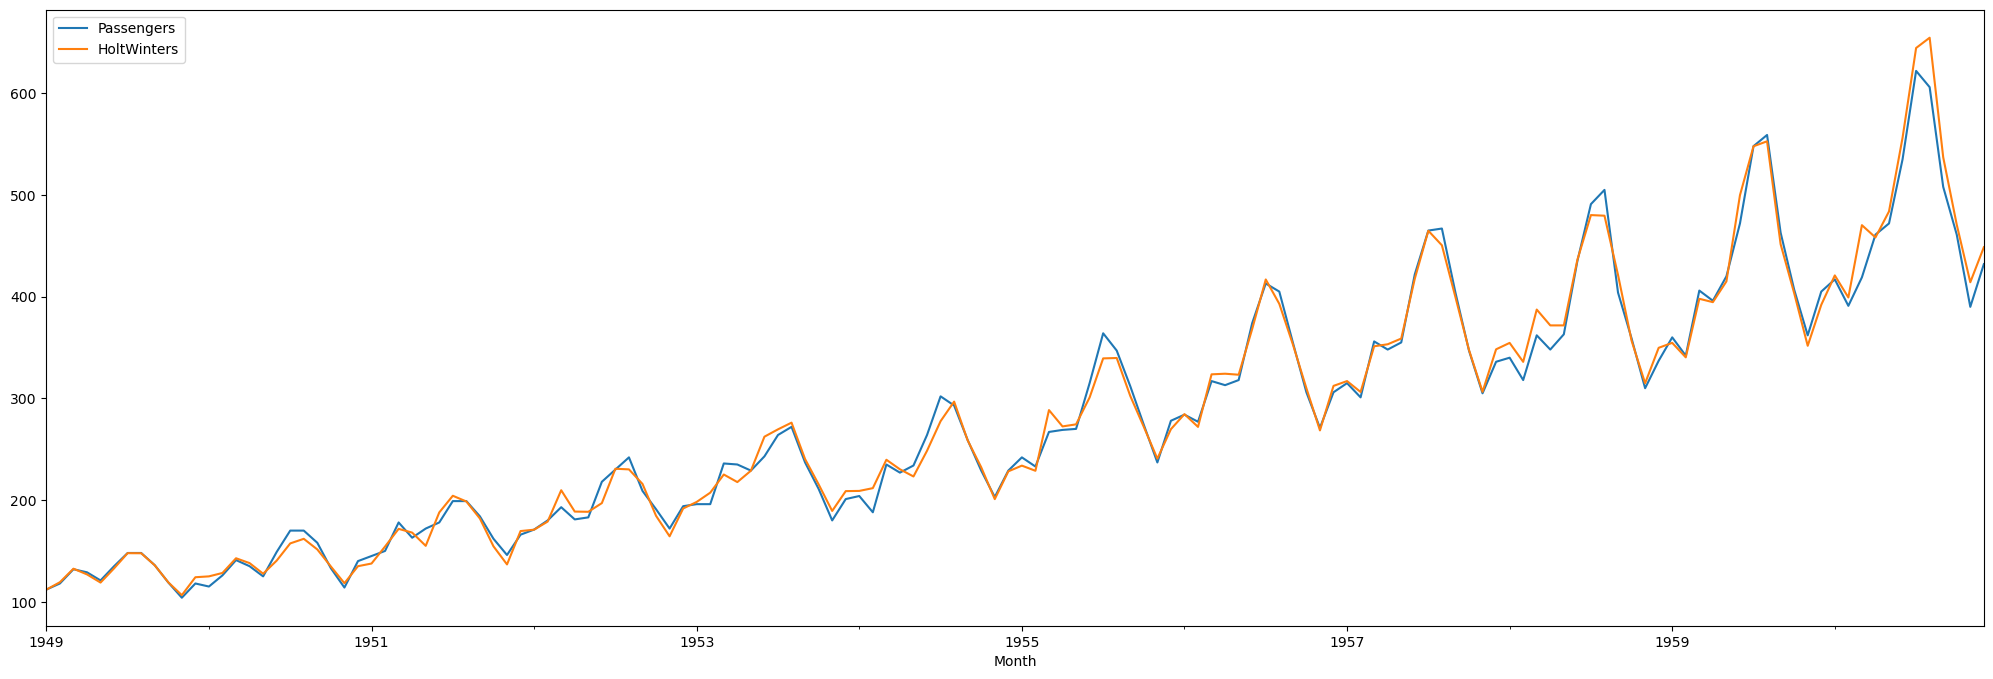

In [34]:
hw = ExponentialSmoothing(
    train['Passengers']
    # , initialization_method = 'legacy-heuristic'
    ,trend ='mul', seasonal ='mul', seasonal_periods = 12)

""" trend might not be a straight line or a curve not visible to naked eye, hence using trend =mul"""
""" seems like the amplitude of seasonality increases with the level of time series hence using seasonal = mul"""

res_hw = hw.fit()
df.loc[train_idx, 'HoltWinters'] = res_hw.fittedvalues
df.loc[test_idx, 'HoltWinters'] = res_hw.forecast(Ntest)    
df[['Passengers','HoltWinters']].plot(figsize = (25,8));

In [35]:
res_hw.params

{'smoothing_level': np.float64(0.36702626567952773),
 'smoothing_trend': np.float64(1.42155935195833e-05),
 'smoothing_seasonal': np.float64(0.6127458210191484),
 'damping_trend': nan,
 'initial_level': np.float64(112.54942016421128),
 'initial_trend': np.float64(1.010297003947589),
 'initial_seasons': array([0.98438078, 1.03786208, 1.14604062, 1.08809034, 1.00282534,
        1.1022594 , 1.20655419, 1.19292495, 1.08544749, 0.94171629,
        0.83369345, 0.97017974]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [36]:
print("Train RMSE:", rmse(train['Passengers'], res_hw.fittedvalues))
print("Test RMSE:", rmse(test['Passengers'], res_hw.forecast(Ntest)))

Train RMSE: 9.618015810961113
Test RMSE: 25.808050789372796


In [37]:
print("Train MAE:", mae(train['Passengers'], res_hw.fittedvalues))
print("Test MAE:", mae(test['Passengers'], res_hw.forecast(Ntest)))

Train MAE: 7.112502526234769
Test MAE: 20.84597775539434


In [38]:
### test error is worse for both metrics - hence not a good fit compared to previous model